# 08 — Guardar figuras y calidad de producción

La diferencia entre un gráfico para exploración y uno para presentar o publicar está en el `figsize`, el `dpi`, los tamaños de fuente, y cómo se guarda el archivo.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root():
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / 'data').exists():
            return parent

ROOT  = find_project_root()
TRAIN = ROOT / 'data' / 'external' / 'train.csv'
AIR   = ROOT / 'data' / 'external' / 'Listings.csv'

import matplotlib.font_manager as fm

df = pd.read_csv(TRAIN, low_memory=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
OUTPUT = ROOT / 'outputs' / 'figures'
OUTPUT.mkdir(parents=True, exist_ok=True)
print('Directorio de salida:', OUTPUT)


Directorio de salida: C:\Users\alefe\OneDrive\Documentos\GitHub\data-analytics-project\outputs\figures


## `savefig()` — guardar en disco

Siempre llamar `savefig()` **antes** de `plt.show()` — después de `show()` el backend limpia la figura.

Archivos guardados en: C:\Users\alefe\OneDrive\Documentos\GitHub\data-analytics-project\outputs\figures


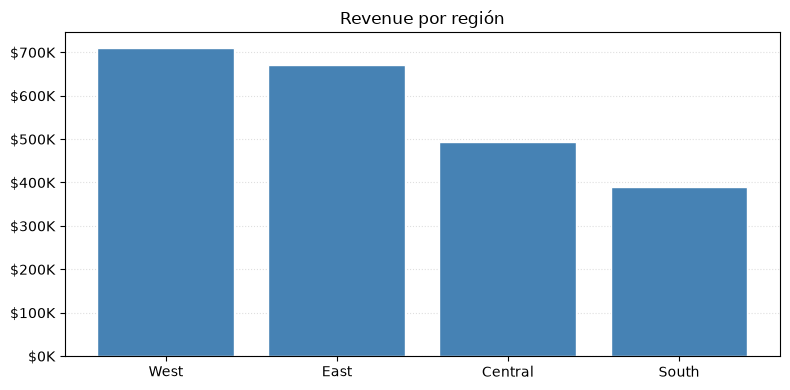

In [2]:
ventas_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ventas_region.index, ventas_region.values,
       color='steelblue', edgecolor='white')
ax.set_title('Revenue por región')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()

# PNG — raster, bueno para web y slides
fig.savefig(OUTPUT / 'ventas_region.png', dpi=150, bbox_inches='tight')

# SVG — vectorial, escala sin perder calidad (perfecto para informes)
fig.savefig(OUTPUT / 'ventas_region.svg', bbox_inches='tight')

# PDF — vectorial, ideal para LaTeX o imprimir
fig.savefig(OUTPUT / 'ventas_region.pdf', bbox_inches='tight')

print('Archivos guardados en:', OUTPUT)
plt.show()


## `bbox_inches='tight'` — qué hace

Sin `bbox_inches='tight'`, el área guardada es exactamente el `figsize` definido. Con él, matplotlib calcula el bounding box real que incluye todos los elementos (título, etiquetas de ejes, leyenda), y guarda ese área sin recortar nada.

Siempre usarlo — los gráficos sin él suelen tener las etiquetas cortadas.

## `dpi` — resolución

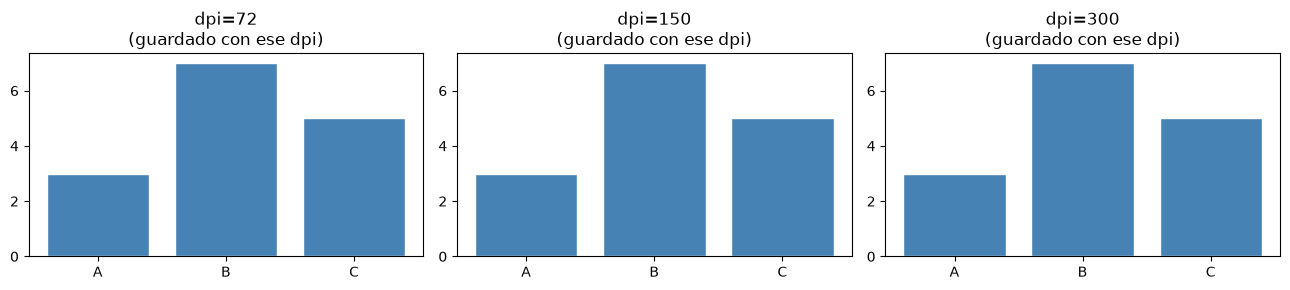

In [3]:
# dpi (dots per inch) determina la resolución del archivo raster (PNG, JPG)
# Para SVG y PDF no tiene efecto — son vectoriales

# Guías prácticas:
# 72 dpi  — calidad de pantalla básica (no usar para nada que se imprima)
# 150 dpi — web, slides, notebooks compartidos
# 300 dpi — impresión, publicaciones, informes formales

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

for ax, dpi_val in zip(axes, [72, 150, 300]):
    ax.bar(['A', 'B', 'C'], [3, 7, 5], color='steelblue', edgecolor='white')
    ax.set_title(f'dpi={dpi_val}\n(guardado con ese dpi)')

plt.tight_layout()

for ax, dpi_val in zip(axes, [72, 150, 300]):
    # Guardar solo el subplot específico — capturar su bbox
    pass  # (requeriría ax.get_window_extent — ejemplo conceptual)

fig.savefig(OUTPUT / 'comparacion_dpi.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico de producción — checklist completo

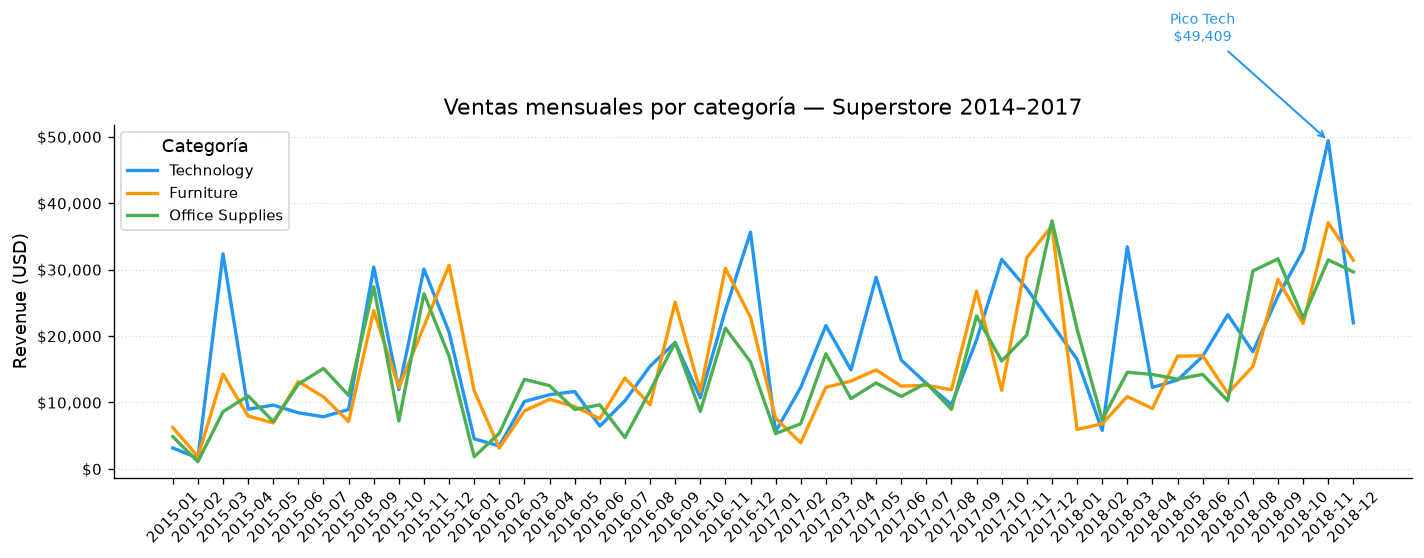

In [4]:
# Configuración para gráfico de presentación
plt.rcParams.update({
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})

ventas_cat_mes = (
    df.groupby([df['Order Date'].dt.to_period('M').astype(str), 'Category'])['Sales']
    .sum()
    .unstack('Category')
)

fig, ax = plt.subplots(figsize=(12, 5))

colores = {'Technology': '#2196F3', 'Furniture': '#FF9800', 'Office Supplies': '#4CAF50'}

for col, color in colores.items():
    ax.plot(ventas_cat_mes.index, ventas_cat_mes[col],
            label=col, color=color, linewidth=2)

# Anotar el máximo de Technology
idx_max = ventas_cat_mes['Technology'].idxmax()
val_max = ventas_cat_mes['Technology'].max()
ax.annotate(
    f'Pico Tech\n${val_max:,.0f}',
    xy=(list(ventas_cat_mes.index).index(idx_max), val_max),
    xytext=(list(ventas_cat_mes.index).index(idx_max) - 5, val_max + 15000),
    fontsize=8.5, color='#2196F3',
    arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.2),
    ha='center',
)

ax.set_title('Ventas mensuales por categoría — Superstore 2014–2017')
ax.set_xlabel('')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Categoría', framealpha=0.8)
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
fig.savefig(OUTPUT / 'ventas_produccion.png', dpi=150, bbox_inches='tight')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)


---
## Checklist para gráfico de producción

- [ ] `figsize` apropiado para el destino (slides: 10×5, informe: 8×4)
- [ ] `dpi=150` para web/slides, `dpi=300` para impresión
- [ ] `bbox_inches='tight'` siempre
- [ ] `savefig()` antes de `plt.show()`
- [ ] Fuentes legibles (mínimo 9pt para etiquetas de eje)
- [ ] `spines.top` y `spines.right` desactivados para aspecto limpio
- [ ] Grilla suave (`:` o `--`, `alpha=0.4`)
- [ ] `set_axisbelow(True)` para que la grilla quede detrás de las barras
- [ ] Formato de números en ejes (`$1,234` en vez de `1234.0`)
- [ ] Anotaciones en puntos clave si la historia lo requiere
